# MagiCoder MBPP Evaluation & Analysis Pipeline

End-to-end pipeline: **model evaluation → code quality analysis → per-task tracking**.

## Sections
1. **Setup** — imports, config, MBPP loading
2. **Evaluation** — runs base + all checkpoints + final LoRA for all 3 model sizes
   - Saves **full generated code** (not truncated)
   - Per-test-case runner: records `tests_passed / tests_total` + error type
3. **Analysis** — reads saved JSONs, no GPU needed
   - Per-task tracking matrix (which tasks were solved at each step)
   - First-solved histogram (when did training unlock each task)
   - Partial credit learning curve (avg tests_passed/total)
   - Error type breakdown (SyntaxError → RuntimeError → AssertionError)
   - AST metrics (syntax validity, function structure, code complexity)
   - Regression analysis (tasks that went backwards)

---
## Section 1 — Setup

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import json as _json_mod
import re, subprocess, tempfile, time, csv, random, math, copy, ast as _ast
from collections import defaultdict
import numpy as np

try:
    from tqdm import tqdm
except ImportError:
    tqdm = lambda x, **kw: x

import torch
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    GenerationConfig, set_seed as hf_set_seed,
)
from peft import PeftModel
from datasets import load_dataset

print(f"PyTorch:  {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:      {torch.cuda.get_device_name(0)}")
    print(f"VRAM:     {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
_sm = torch.cuda.get_device_capability(0)[0] if torch.cuda.is_available() else 0
DTYPE = torch.bfloat16 if _sm >= 8 else torch.float16
print(f"Dtype:    {DTYPE}")

k:\anaconda3\envs\honor\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch:  2.11.0.dev20260205+cu128  |  CUDA: True
GPU:      NVIDIA GeForce RTX 5070 Ti
VRAM:     15.9 GB
Dtype:    torch.bfloat16


In [3]:
HF_MODELS    = r"K:\Honor Project\hf_models"
CHECKPOINTS  = r"K:\Honor Project\checkpoints"
LORA_OUTPUTS = r"K:\Honor Project\lora_outputs"
RESULTS_DIR  = r"K:\Honor Project\mbpp_pipeline_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

MAX_NEW_TOKENS = 512
TEST_TIMEOUT   = 20     # seconds per subprocess execution
FORCE_RERUN    = False  # True = ignore cache and re-run everything

# ── Model configs ─────────────────────────────────────────────────────────────
# 4b has 500-step checkpoints; stride=2 aligns it to 1000-step cadence
MODEL_CONFIGS = [
    {
        "size":       "270m",
        "base":       rf"{HF_MODELS}\gemma-3-270m",
        "ckpt_dir":   rf"{CHECKPOINTS}\ckpt_gemma-3-270m_magicoder",
        "final_lora": rf"{LORA_OUTPUTS}\lora_gemma-3-270m_magicoder",
        "stride":     1,   # checkpoints at 1000-step intervals
    },
    {
        "size":       "1b",
        "base":       rf"{HF_MODELS}\gemma-3-1b-pt",
        "ckpt_dir":   rf"{CHECKPOINTS}\ckpt_gemma-3-1b-pt_magicoder",
        "final_lora": rf"{LORA_OUTPUTS}\lora_gemma-3-1b-pt_magicoder",
        "stride":     1,
    },
    {
        "size":       "4b",
        "base":       rf"{HF_MODELS}\gemma-3-4b-pt",
        "ckpt_dir":   rf"{CHECKPOINTS}\ckpt_gemma-3-4b-pt_magicoder",
        "final_lora": rf"{LORA_OUTPUTS}\lora_gemma-3-4b-pt_magicoder",
        "stride":     1,   # checkpoints at 500-step intervals -> evaluate every other
    },
]

# ── Checkpoint discovery ──────────────────────────────────────────────────────
def get_checkpoints(ckpt_dir, stride=1):
    entries = []
    if not os.path.isdir(ckpt_dir):
        return entries
    for name in os.listdir(ckpt_dir):
        if name.startswith("checkpoint-"):
            try:
                step = int(name.split("-")[1])
                entries.append((step, os.path.join(ckpt_dir, name)))
            except ValueError:
                pass
    entries.sort(key=lambda x: x[0])
    return entries[::stride]

print(f"FORCE_RERUN={FORCE_RERUN}")
print()
print(f"{'size':<6}  {'stride':<6}  {'ckpts':<30}  {'base':<6}  final_lora")
print("-" * 70)
for cfg in MODEL_CONFIGS:
    used = get_checkpoints(cfg["ckpt_dir"], stride=cfg["stride"])
    steps = [s for s, _ in used]
    print(f"{cfg['size']:<6}  {cfg['stride']:<6}  {str(steps):<30}  "
          f"{'OK' if os.path.isdir(cfg['base']) else 'MISSING':<6}  "
          f"{'OK' if os.path.isdir(cfg['final_lora']) else 'MISSING'}")

FORCE_RERUN=False

size    stride  ckpts                           base    final_lora
----------------------------------------------------------------------
270m    1       [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000]  OK      OK
1b      1       [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000]  OK      OK
4b      1       [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000]  OK      OK


In [4]:
print("Loading MBPP (google-research-datasets/mbpp, sanitized, test)...")
try:
    _ds = load_dataset("google-research-datasets/mbpp", "sanitized", split="test")
except Exception as _e:
    print(f"  Fallback: {_e}")
    _ds = load_dataset("mbpp", split="test")

mbpp_problems = []
for _row in _ds:
    _r = dict(_row)
    if "text" not in _r:
        _r["text"] = _r.get("prompt", "")
    if "test_setup_code" not in _r:
        _raw = _r.get("test_imports", "[]") or "[]"
        _imports = _json_mod.loads(_raw) if isinstance(_raw, str) else (_raw or [])
        _r["test_setup_code"] = "\n".join(_imports)
    if isinstance(_r.get("test_list"), str):
        _r["test_list"] = _json_mod.loads(_r["test_list"])
    mbpp_problems.append(_r)

print(f"  {len(mbpp_problems)} problems loaded.")
# Sanity check: test case count distribution
_counts = [len(p["test_list"]) for p in mbpp_problems]
print(f"  Tests per problem: min={min(_counts)} max={max(_counts)} avg={sum(_counts)/len(_counts):.1f}")

Loading MBPP (google-research-datasets/mbpp, sanitized, test)...
  257 problems loaded.
  Tests per problem: min=3 max=5 avg=3.0


---
## Section 2 — Evaluation

Runs **greedy pass@1** (deterministic, no sampling noise) for each model:
- Base model (no LoRA)
- Each checkpoint
- Final LoRA

Each result JSON stores **full generated code** + per-test breakdown.

In [5]:
# ── Seeding ───────────────────────────────────────────────────────────────────
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    hf_set_seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ── Code extraction ───────────────────────────────────────────────────────────
def strip_fences(text):
    m = re.search(r"```(?:python)?\s*(.*?)\s*```", text, re.DOTALL)
    return m.group(1).strip() if m else text.strip()

def extract_func_name(test_list):
    for t in test_list:
        m = re.match(r"\s*assert\s+(\w+)\s*\(", t.strip())
        if m:
            return m.group(1)
    return None

def extract_function(text, func_name=None):
    text = strip_fences(text)
    if func_name:
        pat = rf"(^|\n)(def\s+{re.escape(func_name)}\s*\([\s\S]*?)(?=\n\s*def\s+|\n\s*class\s+|\n\s*if\s+__name__|\Z)"
        m = re.search(pat, text)
        if m:
            return m.group(2).rstrip()
    m2 = re.search(r"(^|\n)(def\s+\w+\s*\([\s\S]*?)(?=\n\s*def\s+|\n\s*class\s+|\n\s*if\s+__name__|\Z)", text)
    return m2.group(2).rstrip() if m2 else text.rstrip()

# ── Per-test runner ───────────────────────────────────────────────────────────
def run_tests_detailed(raw_gen, prob):
    '''
    Run each assert individually.
    Returns dict:
        syntax_valid  : bool   - can ast.parse the extracted code
        tests_passed  : int    - number of passing asserts
        tests_total   : int    - total asserts
        passed_all    : bool   - all asserts passed
        error_type    : str    - SyntaxError|RuntimeError|AssertionError|Timeout|OK
        error_msg     : str    - first error message
    '''
    tests  = prob["test_list"]
    setup  = prob.get("test_setup_code", "") or ""
    fname  = extract_func_name(tests)
    code   = extract_function(raw_gen, fname)

    # Syntax check
    try:
        _ast.parse(code)
        syntax_valid = True
    except SyntaxError:
        syntax_valid = False

    if not syntax_valid:
        return {
            "syntax_valid": False,
            "tests_passed": 0,
            "tests_total":  len(tests),
            "passed_all":   False,
            "error_type":   "SyntaxError",
            "error_msg":    "ast.parse failed",
        }

    # Run each assert individually
    header = (setup.strip() + "\n\n" if setup.strip() else "") + code + "\n\n"
    tests_passed = 0
    first_error_type = "OK"
    first_error_msg  = ""

    for assert_line in tests:
        src = header + assert_line + "\n"
        with tempfile.NamedTemporaryFile(mode="w", suffix=".py",
                                         delete=False, encoding="utf-8") as f:
            f.write(src)
            tmp = f.name
        try:
            r = subprocess.run(["python", tmp], capture_output=True,
                               text=True, timeout=TEST_TIMEOUT)
            if r.returncode == 0:
                tests_passed += 1
            else:
                err_out = (r.stderr or r.stdout or "").strip()
                if first_error_type == "OK":
                    if "AssertionError" in err_out:
                        first_error_type = "AssertionError"
                    elif "SyntaxError" in err_out:
                        first_error_type = "SyntaxError"
                    else:
                        first_error_type = "RuntimeError"
                    first_error_msg = err_out[:200]
        except subprocess.TimeoutExpired:
            if first_error_type == "OK":
                first_error_type = "Timeout"
                first_error_msg  = f"Timed out after {TEST_TIMEOUT}s"
        except Exception as exc:
            if first_error_type == "OK":
                first_error_type = "RuntimeError"
                first_error_msg  = str(exc)[:200]
        finally:
            try:
                os.remove(tmp)
            except Exception:
                pass

    return {
        "syntax_valid": syntax_valid,
        "tests_passed": tests_passed,
        "tests_total":  len(tests),
        "passed_all":   tests_passed == len(tests),
        "error_type":   first_error_type if tests_passed < len(tests) else "OK",
        "error_msg":    first_error_msg,
    }

# ── Prompt builder ────────────────────────────────────────────────────────────
def build_input(prob, tok):
    text, tests = prob["text"], prob["test_list"]
    instr = (
        "Write a Python function to solve the following problem.\n"
        "Output only the Python function — no explanation, no markdown fences.\n\n"
        f"Problem: {text}\n\n"
        "The function must pass these tests:\n" + "\n".join(tests)
    )
    return tok(f"### User:\n{instr}\n### Assistant:\n", return_tensors="pt")

# ── Greedy generation config ──────────────────────────────────────────────────
def make_greedy_cfg(eos_id):
    return GenerationConfig(
        do_sample=False, max_new_tokens=MAX_NEW_TOKENS, pad_token_id=eos_id
    )

# ── Single evaluation run ─────────────────────────────────────────────────────
def evaluate_model(model, tok, problems, label):
    '''
    Greedy pass@1 over all problems.
    Returns (score_pct, n_passed, total, elapsed_sec, per_task_dict)
    per_task_dict keys: task_id -> {code, syntax_valid, tests_passed,
                                    tests_total, passed_all, error_type, error_msg}
    '''
    set_seed(42)
    gen_cfg  = make_greedy_cfg(tok.eos_token_id)
    per_task = {}
    t0       = time.time()

    for prob in tqdm(problems, desc=label, leave=False):
        tid      = prob["task_id"]
        inp      = build_input(prob, tok)
        inp      = {k: v.to(model.device) for k, v in inp.items()}
        inp_len  = inp["input_ids"].shape[1]

        with torch.inference_mode():
            out = model.generate(**inp, generation_config=gen_cfg)
        full_gen = tok.decode(out[0][inp_len:], skip_special_tokens=True)

        result = run_tests_detailed(full_gen, prob)
        result["code"] = full_gen    # save FULL generated code

        per_task[str(tid)] = result

    n_pass  = sum(1 for v in per_task.values() if v["passed_all"])
    total   = len(per_task)
    score   = n_pass / total * 100
    elapsed = time.time() - t0
    return score, n_pass, total, elapsed, per_task

print("Evaluation functions defined.")

Evaluation functions defined.


In [6]:
# ── Evaluation loop ───────────────────────────────────────────────────────────
# Runs base + all checkpoints + final LoRA for each model size.
# Each result saved immediately to RESULTS_DIR as:
#   {size}_{label}.json  — full per-task detail
#   {size}_{label}.csv   — summary row
# Resume-safe: skips already-completed entries unless FORCE_RERUN=True.

eval_summary = []   # list of summary dicts

for cfg in MODEL_CONFIGS:
    size       = cfg["size"]
    base_path  = cfg["base"]
    ckpt_dir   = cfg["ckpt_dir"]
    final_lora = cfg["final_lora"]
    stride     = cfg["stride"]

    if not os.path.isdir(base_path):
        print(f"[SKIP] {size} - base not found")
        continue

    checkpoints = get_checkpoints(ckpt_dir, stride=stride)

    # Plan: base first, then checkpoints, then final LoRA
    plan = [("base", 0, None)]
    for step, ck_path in checkpoints:
        plan.append((f"ckpt_{step}", step, ck_path))
    if os.path.isdir(final_lora):
        plan.append(("final_lora", 10000, final_lora))

    print(f"\n{'='*70}")
    print(f"Model: gemma-3-{size}  |  {len(plan)} entries")
    print(f"  plan: {[l for l,_,_ in plan]}")
    print(f"{'='*70}")

    # Load base on CPU; deepcopy before each LoRA merge
    print(f"  Loading base ({size}) on CPU...")
    _tok = AutoTokenizer.from_pretrained(base_path, local_files_only=True)
    if _tok.pad_token is None:
        _tok.pad_token = _tok.eos_token
    _tok.padding_side = "right"
    _base_model = AutoModelForCausalLM.from_pretrained(
        base_path, local_files_only=True,
        device_map=None, torch_dtype=DTYPE, attn_implementation="sdpa",
    )
    _base_model.config.use_cache = False
    _base_model.eval()
    print("  Base loaded.")

    for label, step, lora_path in plan:
        out_json = os.path.join(RESULTS_DIR, f"{size}_{label}.json")
        out_csv  = os.path.join(RESULTS_DIR, f"{size}_{label}.csv")

        # Resume: skip if already done
        if not FORCE_RERUN and os.path.exists(out_json) and os.path.exists(out_csv):
            with open(out_csv, encoding="utf-8") as f_:
                row = list(csv.DictReader(f_))[0]
            print(f"  [cached] {size}/{label:<18}  {float(row['pass_rate']):.2f}%  ({row['passed']}/{row['total']})")
            eval_summary.append({
                "size": size, "label": label, "step": step,
                "pass_rate": float(row["pass_rate"]),
                "passed": int(row["passed"]), "total": int(row["total"]),
                "runtime_sec": float(row.get("runtime_sec", 0)),
            })
            continue

        # Prepare model
        if lora_path is None:
            print(f"\n  Evaluating base ({size})...")
            if torch.cuda.is_available():
                _base_model = _base_model.to("cuda")
            _model   = _base_model
            _is_base = True
        elif os.path.isdir(lora_path):
            print(f"\n  Merging LoRA: {os.path.basename(lora_path)}...")
            _base_copy = copy.deepcopy(_base_model)
            _model = PeftModel.from_pretrained(_base_copy, lora_path)
            _model = _model.merge_and_unload()
            del _base_copy
            if torch.cuda.is_available():
                _model = _model.to("cuda")
            _is_base = False
        else:
            print(f"  [SKIP] LoRA not found: {lora_path}")
            continue

        _model.eval()

        score, n_pass, total, elapsed, per_task = evaluate_model(
            _model, _tok, mbpp_problems, label=f"{size}/{label}"
        )
        print(f"  {size}/{label:<18}  {score:.2f}%  ({n_pass}/{total})  {elapsed/60:.1f} min")

        # Save full detail JSON
        with open(out_json, "w", encoding="utf-8") as f_:
            _json_mod.dump(per_task, f_, indent=2, ensure_ascii=False)

        # Save summary CSV
        row = {
            "size": size, "label": label, "step": step,
            "pass_rate": round(score, 4), "passed": n_pass, "total": total,
            "runtime_sec": round(elapsed, 1),
        }
        with open(out_csv, "w", newline="", encoding="utf-8") as f_:
            w = csv.DictWriter(f_, fieldnames=list(row.keys()))
            w.writeheader(); w.writerow(row)

        eval_summary.append(row)

        # Cleanup
        if _is_base:
            _base_model = _base_model.cpu()
            torch.cuda.empty_cache()
        else:
            del _model
            torch.cuda.empty_cache()

    del _base_model, _tok
    torch.cuda.empty_cache()
    print(f"\n  Done with {size}.")

# Print summary table
print(f"\n{'='*60}")
print("EVALUATION SUMMARY")
print(f"{'='*60}")
print(f"  {'size':<6} {'label':<20} {'step':>6}  {'pass@1(%)':>10}  {'passed':>8}")
print(f"  {'-'*55}")
for r in eval_summary:
    print(f"  {r['size']:<6} {r['label']:<20} {r['step']:>6}  {r['pass_rate']:>10.2f}  {r['passed']:>8}/{r['total']}")
print(f"\nAll results saved to: {RESULTS_DIR}")


Model: gemma-3-270m  |  11 entries
  plan: ['base', 'ckpt_1000', 'ckpt_2000', 'ckpt_3000', 'ckpt_4000', 'ckpt_5000', 'ckpt_6000', 'ckpt_7000', 'ckpt_8000', 'ckpt_9000', 'final_lora']
  Loading base (270m) on CPU...


`torch_dtype` is deprecated! Use `dtype` instead!


  Base loaded.

  Evaluating base (270m)...


270m/base:   0%|          | 0/257 [00:00<?, ?it/s]`generation_config` default values have been modified to match model-specific defaults: {'do_sample': True, 'top_k': 64, 'top_p': 0.95}. If this is not desired, please set these values explicitly.


  270m/base                0.00%  (0/257)  50.8 min

  Merging LoRA: checkpoint-1000...


...

  4b/ckpt_6000           46.30%  (119/257)  38.6 min

  Merging LoRA: checkpoint-7000...


  4b/ckpt_7000           48.25%  (124/257)  39.7 min

  Merging LoRA: checkpoint-8000...


  4b/ckpt_8000           46.69%  (120/257)  41.3 min

  Merging LoRA: checkpoint-9000...


  4b/ckpt_9000           50.58%  (130/257)  37.4 min

  Merging LoRA: lora_gemma-3-4b-pt_magicoder...


  4b/final_lora          48.64%  (125/257)  37.8 min

  Done with 4b.

EVALUATION SUMMARY
  size   label                  step   pass@1(%)    passed
  -------------------------------------------------------
  270m   base                      0        0.00         0/257
  270m   ckpt_1000              1000        0.78         2/257
  270m   ckpt_2000              2000        0.39         1/257
  270m   ckpt_3000              3000        1.56         4/257
  270m   ckpt_4000              4000        0.39         1/257
  270m   ckpt_5000              5000        1.17         3/257
  270m   ckpt_6000              6000        0.39         1/257
  270m   ckpt_7000              7000        0.78         2/257
  270m   ckpt_8000              8000        0.78         2/257
  270m   ckpt_9000              9000        0.78         2/257
  270m   final_lora            10000        0.78         2/257
  1b     base                      0        0.78         2/257
  1b     ckpt_1000              1000 

---
## Section 3 — Analysis

Reads saved JSON files. **No GPU required** — run this section independently after evaluation completes.

Each analysis cell is independent — re-run any cell without re-running the others.

In [7]:
# ── Load all saved result JSONs ───────────────────────────────────────────────
import os, json, math, re, ast as _ast
from collections import defaultdict

RESULTS_DIR = r"K:\Honor Project\mbpp_pipeline_results"

def load_all_results():
    """
    Returns dict: (size, label, step) -> per_task_dict
    per_task_dict: task_id -> {code, syntax_valid, tests_passed, tests_total,
                               passed_all, error_type, error_msg}
    """
    results = {}
    if not os.path.isdir(RESULTS_DIR):
        print(f"Results dir not found: {RESULTS_DIR}")
        return results
    for fname in sorted(os.listdir(RESULTS_DIR)):
        if not fname.endswith(".json"):
            continue
        # Parse filename: {size}_{label}.json
        # label examples: base, ckpt_1000, ckpt_9000, final_lora
        parts = fname.replace(".json", "").split("_", 1)
        if len(parts) != 2:
            continue
        size, label = parts
        # Determine step from label
        if label == "base":
            step = 0
        elif label == "final_lora":
            step = 10000
        elif label.startswith("ckpt_"):
            try:
                step = int(label.split("_")[1])
            except ValueError:
                continue
        else:
            continue
        fpath = os.path.join(RESULTS_DIR, fname)
        with open(fpath, encoding="utf-8") as f:
            data = json.load(f)
        results[(size, label, step)] = data
    return results

all_results = load_all_results()

# Ordered plan per size for consistent display
SIZE_ORDER  = ["270m", "1b", "4b"]
LABEL_ORDER_FN = lambda label: (
    0 if label == "base" else
    (2 if label == "final_lora" else
     (1, int(label.split("_")[1]) if label.startswith("ckpt_") else 0))
)

def get_ordered_labels(size):
    labels = [(label, step) for (s, label, step) in all_results if s == size]
    return sorted(labels, key=lambda x: (0 if x[0]=="base" else (2 if x[0]=="final_lora" else 1), x[1]))

# Summary
print(f"Loaded {len(all_results)} result files.")
for size in SIZE_ORDER:
    labels = get_ordered_labels(size)
    if labels:
        print(f"  {size}: {[l for l,_ in labels]}")

Loaded 33 result files.
  270m: ['base', 'ckpt_1000', 'ckpt_2000', 'ckpt_3000', 'ckpt_4000', 'ckpt_5000', 'ckpt_6000', 'ckpt_7000', 'ckpt_8000', 'ckpt_9000', 'final_lora']
  1b: ['base', 'ckpt_1000', 'ckpt_2000', 'ckpt_3000', 'ckpt_4000', 'ckpt_5000', 'ckpt_6000', 'ckpt_7000', 'ckpt_8000', 'ckpt_9000', 'final_lora']
  4b: ['base', 'ckpt_1000', 'ckpt_2000', 'ckpt_3000', 'ckpt_4000', 'ckpt_5000', 'ckpt_6000', 'ckpt_7000', 'ckpt_8000', 'ckpt_9000', 'final_lora']


### Cell A — Score Summary

In [8]:
# ── Cell A: Score summary table ───────────────────────────────────────────────
print(f"{'='*65}")
print(f"  MBPP pass@1 (greedy) — binary all-tests-pass rate")
print(f"{'='*65}")
print(f"  {'size':<6} {'label':<20} {'step':>6}  {'pass@1%':>8}  {'passed':>8}")
print(f"  {'-'*55}")
for size in SIZE_ORDER:
    for label, step in get_ordered_labels(size):
        data = all_results.get((size, label, step), {})
        if not data:
            continue
        n_pass = sum(1 for v in data.values() if v["passed_all"])
        total  = len(data)
        pct    = n_pass / total * 100
        flag   = " <- base" if label=="base" else (" <- final" if label=="final_lora" else "")
        print(f"  {size:<6} {label:<20} {step:>6}  {pct:>8.2f}  {n_pass:>6}/{total}{flag}")
    print()

  MBPP pass@1 (greedy) — binary all-tests-pass rate
  size   label                  step   pass@1%    passed
  -------------------------------------------------------
  270m   base                      0      0.00       0/257 <- base
  270m   ckpt_1000              1000      0.78       2/257
  270m   ckpt_2000              2000      0.39       1/257
  270m   ckpt_3000              3000      1.56       4/257
  270m   ckpt_4000              4000      0.39       1/257
  270m   ckpt_5000              5000      1.17       3/257
  270m   ckpt_6000              6000      0.39       1/257
  270m   ckpt_7000              7000      0.78       2/257
  270m   ckpt_8000              8000      0.78       2/257
  270m   ckpt_9000              9000      0.78       2/257
  270m   final_lora            10000      0.78       2/257 <- final

  1b     base                      0      0.78       2/257 <- base
  1b     ckpt_1000              1000      4.67      12/257
  1b     ckpt_2000              2000    

### Cell B — Per-task Tracking Heatmap


  Per-task tracking: 270m
  Total tasks:    257
  Always passed:  0  (base already solved, never lost)
  Unlocked:       9  (base failed, training solved)
  Regressed:      0  (base solved, training broke)
  Never solved:   248  (no checkpoint solved this)


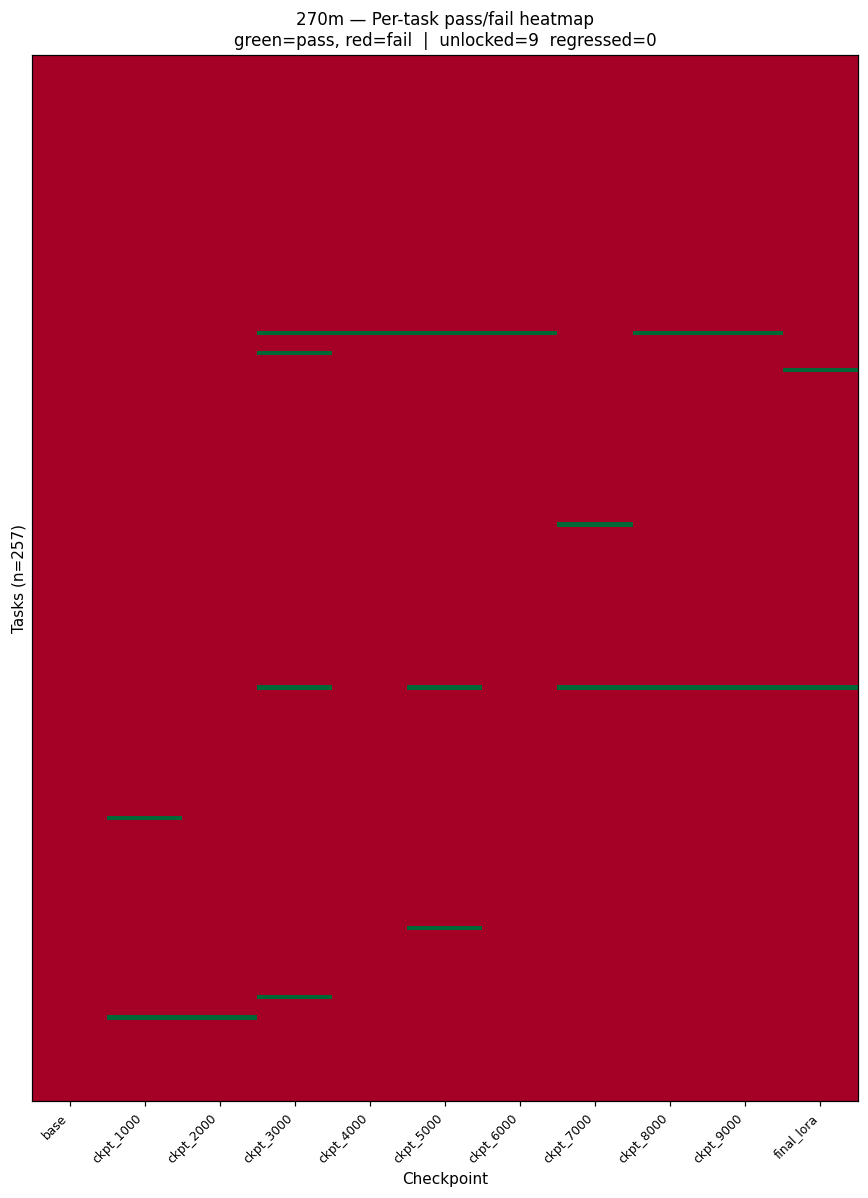

  Heatmap saved.

  Per-task tracking: 1b
  Total tasks:    257
  Always passed:  0  (base already solved, never lost)
  Unlocked:       64  (base failed, training solved)
  Regressed:      2  (base solved, training broke)
  Never solved:   191  (no checkpoint solved this)


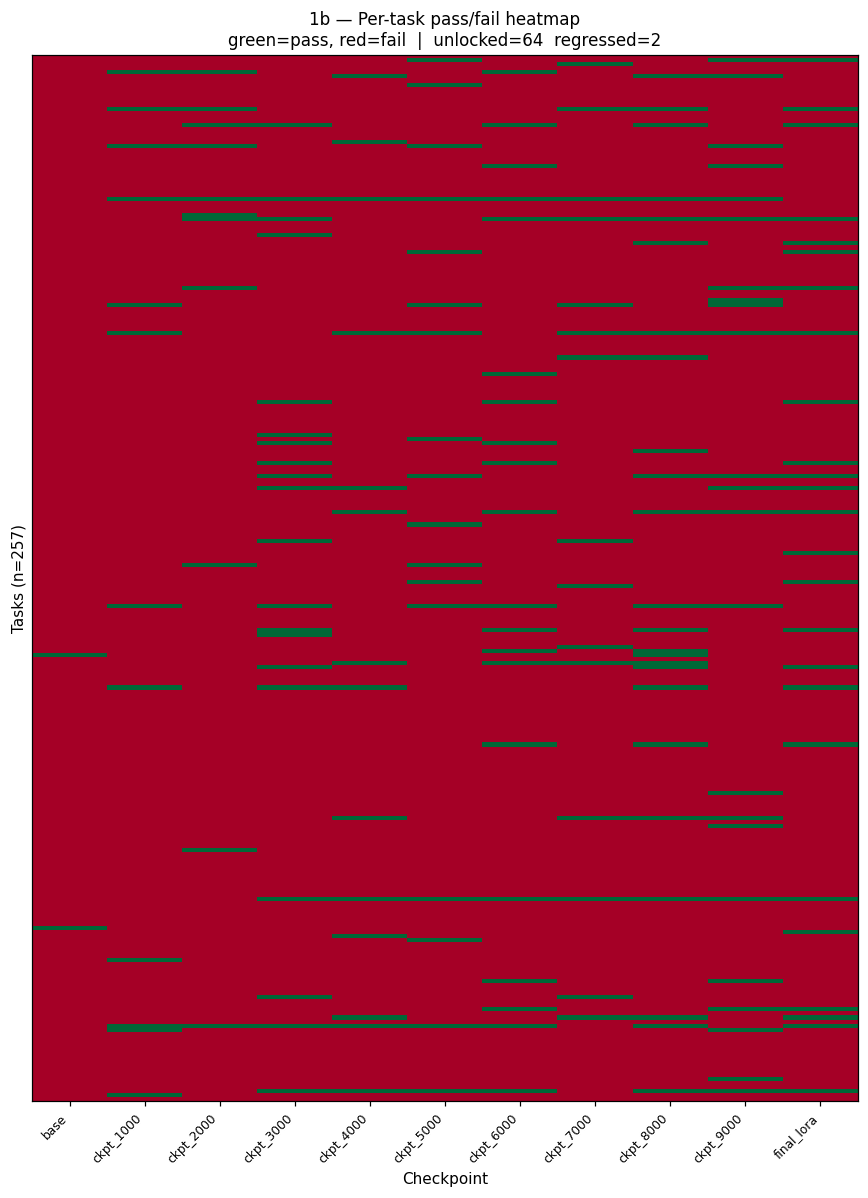

  Heatmap saved.

  Per-task tracking: 4b
  Total tasks:    257
  Always passed:  22  (base already solved, never lost)
  Unlocked:       136  (base failed, training solved)
  Regressed:      16  (base solved, training broke)
  Never solved:   60  (no checkpoint solved this)


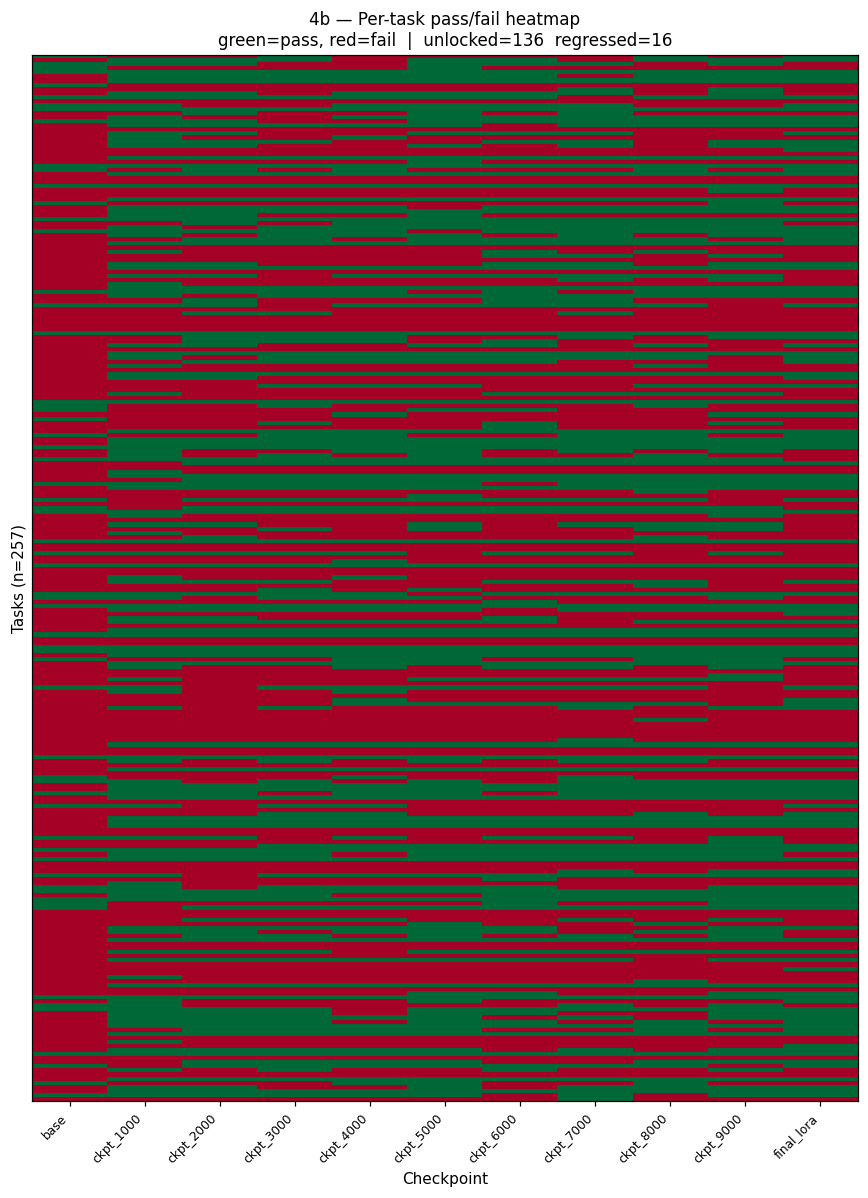

  Heatmap saved.


In [9]:
# ── Cell B: Per-task tracking matrix ─────────────────────────────────────────
# For each task: which labels solved it?
# Reveals: unlocked / regressed / always / never

try:
    import matplotlib.pyplot as plt
    import matplotlib
    matplotlib.rcParams["figure.dpi"] = 110
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

for size in SIZE_ORDER:
    ordered = get_ordered_labels(size)
    if not ordered:
        continue

    labels = [l for l, _ in ordered]
    all_task_ids = sorted(all_results[(size, ordered[0][0], ordered[0][1])].keys(),
                          key=lambda x: int(x)) if ordered else []
    if not all_task_ids:
        continue

    # Build matrix: rows=tasks, cols=labels, value=passed_all
    matrix = {}
    for tid in all_task_ids:
        matrix[tid] = {}
        for label, step in ordered:
            data = all_results.get((size, label, step), {})
            matrix[tid][label] = data.get(tid, {}).get("passed_all", False)

    # Categorise tasks
    base_label = ordered[0][0]   # "base"
    final_label = ordered[-1][0] # "final_lora" or last ckpt

    unlocked   = [t for t in all_task_ids if not matrix[t].get(base_label) and any(matrix[t].get(l) for l in labels[1:])]
    regressed  = [t for t in all_task_ids if matrix[t].get(base_label) and not matrix[t].get(final_label)]
    always_pass= [t for t in all_task_ids if all(matrix[t].get(l) for l in labels)]
    never_pass = [t for t in all_task_ids if not any(matrix[t].get(l) for l in labels)]

    print(f"\n{'='*60}")
    print(f"  Per-task tracking: {size}")
    print(f"{'='*60}")
    print(f"  Total tasks:    {len(all_task_ids)}")
    print(f"  Always passed:  {len(always_pass)}  (base already solved, never lost)")
    print(f"  Unlocked:       {len(unlocked)}  (base failed, training solved)")
    print(f"  Regressed:      {len(regressed)}  (base solved, training broke)")
    print(f"  Never solved:   {len(never_pass)}  (no checkpoint solved this)")

    if HAS_MPL and len(all_task_ids) > 0:
        import numpy as np
        grid = np.array([[1 if matrix[tid].get(l, False) else 0
                          for l in labels]
                         for tid in all_task_ids], dtype=float)
        fig, ax = plt.subplots(figsize=(max(8, len(labels)*0.7), min(12, len(all_task_ids)*0.035 + 2)))
        im = ax.imshow(grid, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
        ax.set_yticks([])
        ax.set_xlabel("Checkpoint", fontsize=10)
        ax.set_ylabel(f"Tasks (n={len(all_task_ids)})", fontsize=10)
        ax.set_title(f"{size} — Per-task pass/fail heatmap\n"
                     f"green=pass, red=fail  |  unlocked={len(unlocked)}  regressed={len(regressed)}",
                     fontsize=11)
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f"{size}_task_heatmap.png"), bbox_inches="tight")
        plt.show()
        print(f"  Heatmap saved.")

### Cell C — First-Solved Histogram


  First-solved distribution: 270m
  step  1000:   2 tasks  ##
  step  2000:   0 tasks  
  step  3000:   4 tasks  ####
  step  4000:   0 tasks  
  step  5000:   1 tasks  #
  step  6000:   0 tasks  
  step  7000:   1 tasks  #
  step  8000:   0 tasks  
  step  9000:   0 tasks  
  step 10000:   1 tasks  #
  Total unlocked: 9


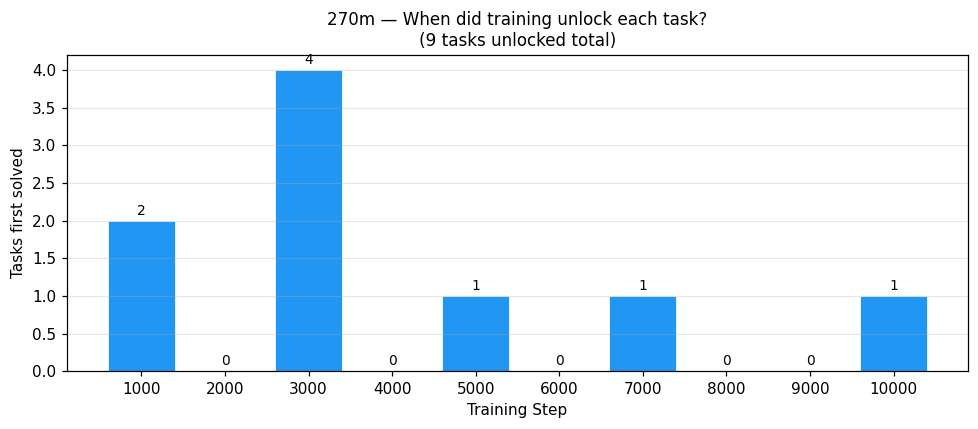

  Plot saved.

  First-solved distribution: 1b
  step  1000:  12 tasks  ############
  step  2000:   6 tasks  ######
  step  3000:  14 tasks  ##############
  step  4000:   7 tasks  #######
  step  5000:   7 tasks  #######
  step  6000:   6 tasks  ######
  step  7000:   4 tasks  ####
  step  8000:   2 tasks  ##
  step  9000:   4 tasks  ####
  step 10000:   2 tasks  ##
  Total unlocked: 64


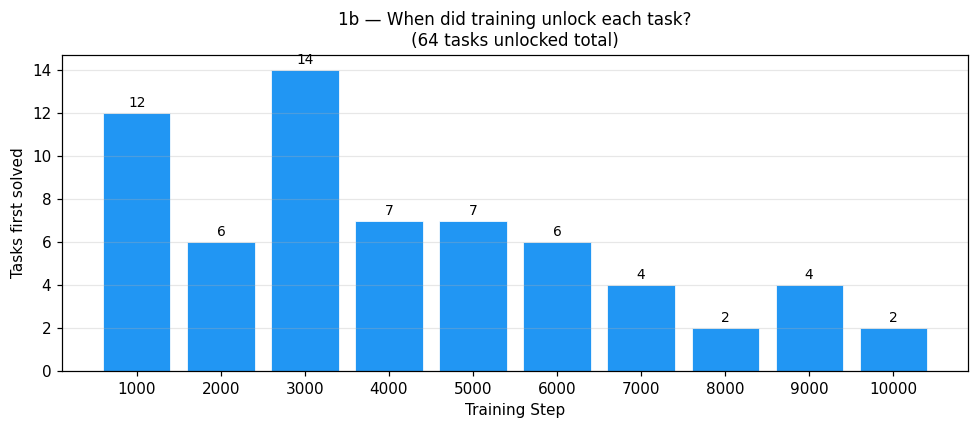

  Plot saved.

  First-solved distribution: 4b
  step  1000:  87 tasks  #######################################################################################
  step  2000:  15 tasks  ###############
  step  3000:   6 tasks  ######
  step  4000:   4 tasks  ####
  step  5000:   4 tasks  ####
  step  6000:   4 tasks  ####
  step  7000:   5 tasks  #####
  step  8000:   4 tasks  ####
  step  9000:   3 tasks  ###
  step 10000:   4 tasks  ####
  Total unlocked: 136


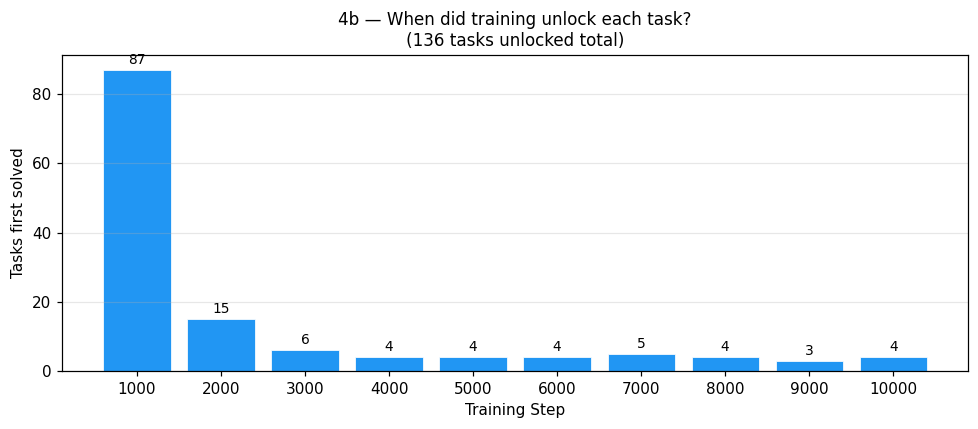

  Plot saved.


In [10]:
# ── Cell C: First-solved histogram ───────────────────────────────────────────
# For each unlocked task: at which step was it first solved?

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

for size in SIZE_ORDER:
    ordered = get_ordered_labels(size)
    if not ordered:
        continue
    labels = [l for l, _ in ordered]
    steps  = [s for _, s in ordered]
    all_task_ids = sorted(all_results.get((size, ordered[0][0], ordered[0][1]), {}).keys(),
                          key=lambda x: int(x))
    if not all_task_ids:
        continue

    base_label = ordered[0][0]
    first_solved_at = {}   # task_id -> step when first solved (excluding base)

    for tid in all_task_ids:
        base_data = all_results.get((size, base_label, 0), {})
        if base_data.get(tid, {}).get("passed_all"):
            continue  # already solved by base, not "unlocked"
        for label, step in ordered[1:]:
            data = all_results.get((size, label, step), {})
            if data.get(tid, {}).get("passed_all"):
                first_solved_at[tid] = step
                break

    if not first_solved_at:
        print(f"  {size}: no tasks unlocked by training")
        continue

    from collections import Counter
    counts = Counter(first_solved_at.values())
    all_steps = sorted(set(steps[1:]))  # exclude base step 0

    print(f"\n{'='*50}")
    print(f"  First-solved distribution: {size}")
    print(f"{'='*50}")
    total_unlocked = len(first_solved_at)
    for st in all_steps:
        c = counts.get(st, 0)
        bar = "#" * c
        print(f"  step {st:>5}: {c:>3} tasks  {bar}")
    print(f"  Total unlocked: {total_unlocked}")

    if HAS_MPL:
        import numpy as np
        fig, ax = plt.subplots(figsize=(9, 4))
        xs = [str(s) for s in all_steps]
        ys = [counts.get(s, 0) for s in all_steps]
        bars = ax.bar(xs, ys, color="#2196F3", edgecolor="white", linewidth=0.5)
        ax.bar_label(bars, padding=2, fontsize=9)
        ax.set_xlabel("Training Step", fontsize=10)
        ax.set_ylabel("Tasks first solved", fontsize=10)
        ax.set_title(f"{size} — When did training unlock each task?\n"
                     f"({total_unlocked} tasks unlocked total)", fontsize=11)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f"{size}_first_solved.png"), bbox_inches="tight")
        plt.show()
        print(f"  Plot saved.")

### Cell D — Partial Credit Learning Curve


270m — Binary pass@1 vs Partial credit:
  label                  step   binary%    partial%
  base                      0      0.00        0.00
  ckpt_1000              1000      0.78        2.46
  ckpt_2000              2000      0.39        1.30
  ckpt_3000              3000      1.56        3.06
  ckpt_4000              4000      0.39        2.08
  ckpt_5000              5000      1.17        2.09
  ckpt_6000              6000      0.39        2.28
  ckpt_7000              7000      0.78        2.28
  ckpt_8000              8000      0.78        2.02
  ckpt_9000              9000      0.78        2.08
  final_lora            10000      0.78        2.08

1b — Binary pass@1 vs Partial credit:
  label                  step   binary%    partial%
  base                      0      0.78        0.78
  ckpt_1000              1000      4.67        7.39
  ckpt_2000              2000      4.28        6.42
  ckpt_3000              3000      7.78       10.25
  ckpt_4000              4000      5

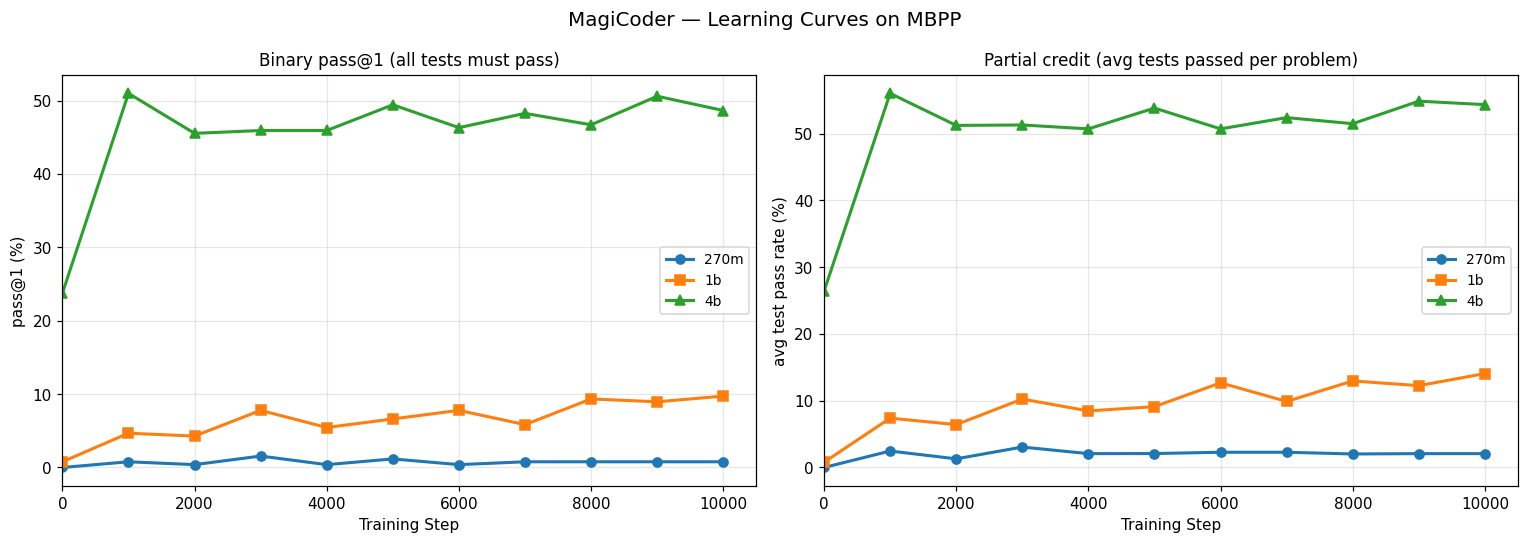


Learning curve plot saved.


In [11]:
# ── Cell D: Partial credit learning curve ────────────────────────────────────
# avg(tests_passed / tests_total) per checkpoint — smoother than binary pass rate

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

colors  = {"270m": "#1f77b4", "1b": "#ff7f0e", "4b": "#2ca02c"}
markers = {"270m": "o", "1b": "s", "4b": "^"}

if HAS_MPL:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for size in SIZE_ORDER:
    ordered = get_ordered_labels(size)
    if not ordered:
        continue

    binary_pts  = []  # (step, pass@1%)
    partial_pts = []  # (step, avg partial credit %)

    for label, step in ordered:
        data = all_results.get((size, label, step), {})
        if not data:
            continue
        n_pass   = sum(1 for v in data.values() if v["passed_all"])
        partial  = sum(v["tests_passed"] / v["tests_total"]
                       for v in data.values() if v["tests_total"] > 0)
        n        = len(data)
        binary_pts.append((step, n_pass / n * 100))
        partial_pts.append((step, partial / n * 100))

    print(f"\n{size} — Binary pass@1 vs Partial credit:")
    print(f"  {'label':<20} {'step':>6}  {'binary%':>8}  {'partial%':>10}")
    for (label, step), (_, b), (_, p) in zip(ordered, binary_pts, partial_pts):
        print(f"  {label:<20} {step:>6}  {b:>8.2f}  {p:>10.2f}")

    if HAS_MPL and binary_pts:
        xs = [x for x, _ in binary_pts]
        ys_b = [y for _, y in binary_pts]
        ys_p = [y for _, y in partial_pts]
        ax1.plot(xs, ys_b, marker=markers[size], color=colors[size],
                 label=size, linewidth=2, markersize=6)
        ax2.plot(xs, ys_p, marker=markers[size], color=colors[size],
                 label=size, linewidth=2, markersize=6)

if HAS_MPL:
    for ax, title, ylabel in [
        (ax1, "Binary pass@1 (all tests must pass)", "pass@1 (%)"),
        (ax2, "Partial credit (avg tests passed per problem)", "avg test pass rate (%)"),
    ]:
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Training Step", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(left=0)
    fig.suptitle("MagiCoder — Learning Curves on MBPP", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "learning_curves.png"), bbox_inches="tight")
    plt.show()
    print("\nLearning curve plot saved.")

### Cell E — Error Type Breakdown


  Error breakdown: 270m
  label                 SyntaxErro  RuntimeErr     Timeout  AssertionE          OK
  ------------------------------------------------------------
  base                       92.6%        7.4%        0.0%        0.0%        0.0%
  ckpt_1000                  10.9%       65.4%        0.4%       22.6%        0.8%
  ckpt_2000                  14.8%       65.0%        0.4%       19.5%        0.4%
  ckpt_3000                  10.5%       68.1%        0.4%       19.5%        1.6%
  ckpt_4000                  13.6%       66.5%        0.4%       19.1%        0.4%
  ckpt_5000                  10.5%       70.0%        0.4%       17.9%        1.2%
  ckpt_6000                  12.5%       66.5%        0.0%       20.6%        0.4%
  ckpt_7000                  10.5%       66.9%        0.8%       21.0%        0.8%
  ckpt_8000                  11.7%       66.9%        0.0%       20.6%        0.8%
  ckpt_9000                  12.8%       65.8%        0.0%       20.6%        0.8%

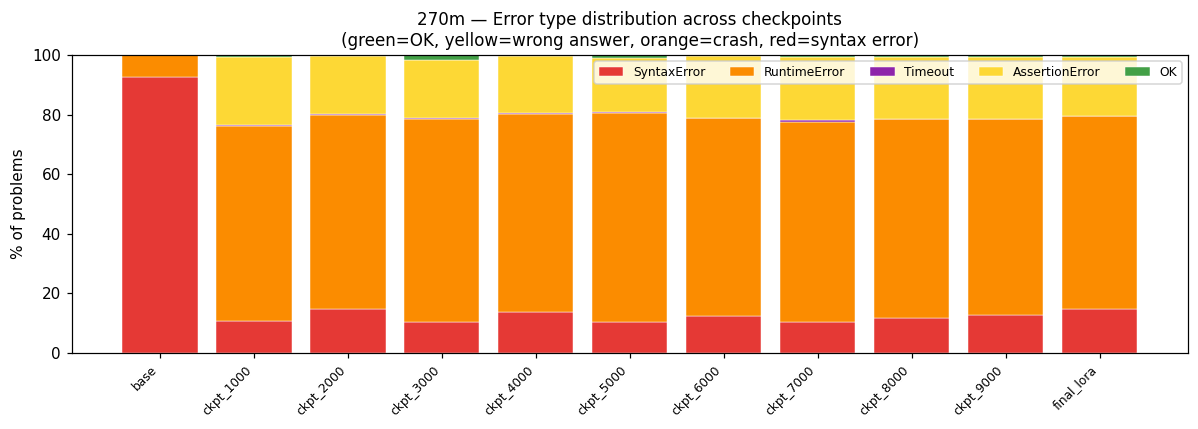

  Plot saved.

  Error breakdown: 1b
  label                 SyntaxErro  RuntimeErr     Timeout  AssertionE          OK
  ------------------------------------------------------------
  base                       82.9%       12.1%        0.0%        4.3%        0.8%
  ckpt_1000                  13.2%       39.7%        0.0%       42.4%        4.7%
  ckpt_2000                  26.1%       29.6%        0.8%       39.3%        4.3%
  ckpt_3000                  14.0%       34.6%        1.6%       42.0%        7.8%
  ckpt_4000                  11.3%       35.8%        0.0%       47.5%        5.4%
  ckpt_5000                  19.8%       32.7%        0.4%       40.5%        6.6%
  ckpt_6000                   3.1%       37.0%        1.6%       50.6%        7.8%
  ckpt_7000                  10.5%       36.6%        0.8%       46.3%        5.8%
  ckpt_8000                  10.5%       35.8%        1.2%       43.2%        9.3%
  ckpt_9000                   9.7%       35.8%        0.8%       44.7%

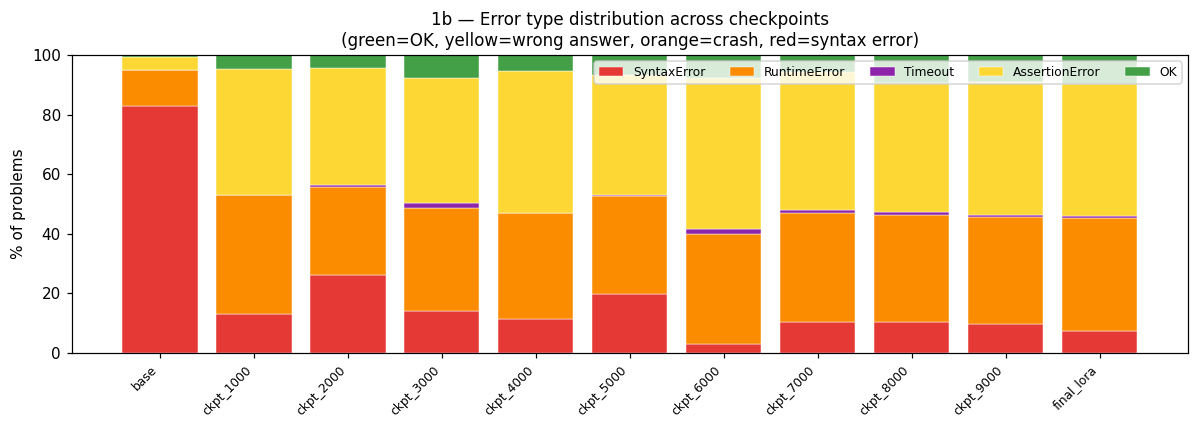

  Plot saved.

  Error breakdown: 4b
  label                 SyntaxErro  RuntimeErr     Timeout  AssertionE          OK
  ------------------------------------------------------------
  base                       38.9%       16.0%        0.4%       21.0%       23.7%
  ckpt_1000                   2.3%        8.9%        0.0%       37.7%       51.0%
  ckpt_2000                   2.3%       19.1%        0.0%       33.1%       45.5%
  ckpt_3000                   1.2%       17.9%        0.0%       35.0%       45.9%
  ckpt_4000                   3.9%       11.7%        0.4%       38.1%       45.9%
  ckpt_5000                   1.9%       14.0%        0.0%       34.6%       49.4%
  ckpt_6000                   3.1%       16.7%        0.4%       33.5%       46.3%
  ckpt_7000                   2.3%       15.6%        0.4%       33.5%       48.2%
  ckpt_8000                   2.7%       16.0%        0.8%       33.9%       46.7%
  ckpt_9000                   0.8%       14.8%        0.4%       33.5%

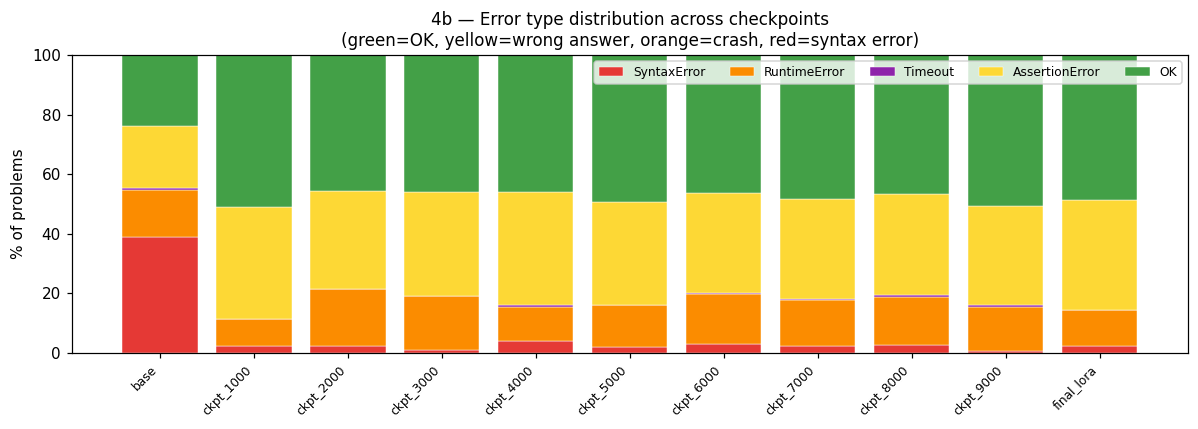

  Plot saved.


In [12]:
# ── Cell E: Error type breakdown per checkpoint ───────────────────────────────
# SyntaxError -> RuntimeError -> AssertionError -> OK
# Shows model progression: first learns syntax, then logic

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

ERROR_TYPES   = ["SyntaxError", "RuntimeError", "Timeout", "AssertionError", "OK"]
ERROR_COLORS  = {"SyntaxError": "#e53935", "RuntimeError": "#FB8C00",
                 "Timeout": "#8E24AA", "AssertionError": "#FDD835", "OK": "#43A047"}

for size in SIZE_ORDER:
    ordered = get_ordered_labels(size)
    if not ordered:
        continue

    print(f"\n{'='*65}")
    print(f"  Error breakdown: {size}")
    print(f"{'='*65}")
    hdr = f"  {'label':<20}"
    for et in ERROR_TYPES:
        hdr += f"  {et[:10]:>10}"
    print(hdr)
    print(f"  {'-'*60}")

    all_rows = []
    for label, step in ordered:
        data = all_results.get((size, label, step), {})
        if not data:
            continue
        counts = defaultdict(int)
        for v in data.values():
            counts[v.get("error_type", "OK")] += 1
        n = len(data)
        row_str = f"  {label:<20}"
        row_data = {}
        for et in ERROR_TYPES:
            c = counts.get(et, 0)
            pct = c / n * 100
            row_str += f"  {pct:>9.1f}%"
            row_data[et] = pct
        print(row_str)
        all_rows.append((label, step, row_data))

    if HAS_MPL and all_rows:
        import numpy as np
        fig, ax = plt.subplots(figsize=(11, 4))
        x_labels = [r[0] for r in all_rows]
        xs = np.arange(len(x_labels))
        bottoms = np.zeros(len(xs))
        for et in ERROR_TYPES:
            ys = np.array([r[2].get(et, 0) for r in all_rows])
            ax.bar(xs, ys, bottom=bottoms, label=et,
                   color=ERROR_COLORS[et], edgecolor="white", linewidth=0.3)
            bottoms += ys
        ax.set_xticks(xs)
        ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("% of problems", fontsize=10)
        ax.set_title(f"{size} — Error type distribution across checkpoints\n"
                     f"(green=OK, yellow=wrong answer, orange=crash, red=syntax error)",
                     fontsize=11)
        ax.legend(loc="upper right", fontsize=8, ncol=len(ERROR_TYPES))
        ax.set_ylim(0, 100)
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f"{size}_error_breakdown.png"), bbox_inches="tight")
        plt.show()
        print(f"  Plot saved.")

### Cell F — AST Code Quality Metrics

  AST Metrics per checkpoint (% of 257 problems)
  label                 syntx%   def%   ret%   loop%   cond%   bltn%   fnlen  fence%
  ---------------------------------------------------------------------------

  -- 270m --
  base                     0.0    0.0    0.0     0.0     0.0     0.0     0.0     8.2
  ckpt_1000                0.0    0.0    0.0     0.0     0.0     0.0     0.0   100.0
  ckpt_2000                0.0    0.0    0.0     0.0     0.0     0.0     0.0   100.0
  ckpt_3000                0.0    0.0    0.0     0.0     0.0     0.0     0.0    99.6
  ckpt_4000                0.0    0.0    0.0     0.0     0.0     0.0     0.0   100.0
  ckpt_5000                0.4    0.4    0.4     0.0     0.4     0.4     0.0    99.2
  ckpt_6000                0.0    0.0    0.0     0.0     0.0     0.0     0.0   100.0
  ckpt_7000                0.0    0.0    0.0     0.0     0.0     0.0     0.0    99.6
  ckpt_8000                0.0    0.0    0.0     0.0     0.0     0.0     0.0   100.0
  ckpt_90

<unknown>:10: SyntaxWarning: invalid decimal literal


  ckpt_1000               12.5   12.5   12.5     5.8     7.4    10.1     0.9    86.8
  ckpt_2000                5.1    5.1    5.1     1.9     1.6     4.3     0.2    94.6
  ckpt_3000               12.8   12.8   12.8     4.3     4.7     9.3     0.8    86.8
  ckpt_4000               41.2   41.2   41.2    16.7    16.7    30.7     2.8    56.0
  ckpt_5000                9.3    9.3    9.3     3.9     2.3     7.8     0.5    90.7
  ckpt_6000               18.3   18.3   18.3     5.4     6.2    13.2     0.9    78.2
  ckpt_7000               20.2   20.2   20.2     7.8     8.6    12.1     1.1    77.0
  ckpt_8000               19.5   19.5   19.1     8.9     8.6    12.8     1.2    79.0
  ckpt_9000               26.5   26.5   26.5     8.9    10.1    16.7     1.4    73.2
  final_lora              28.0   28.0   28.0    11.3    10.5    18.7     1.7    70.8


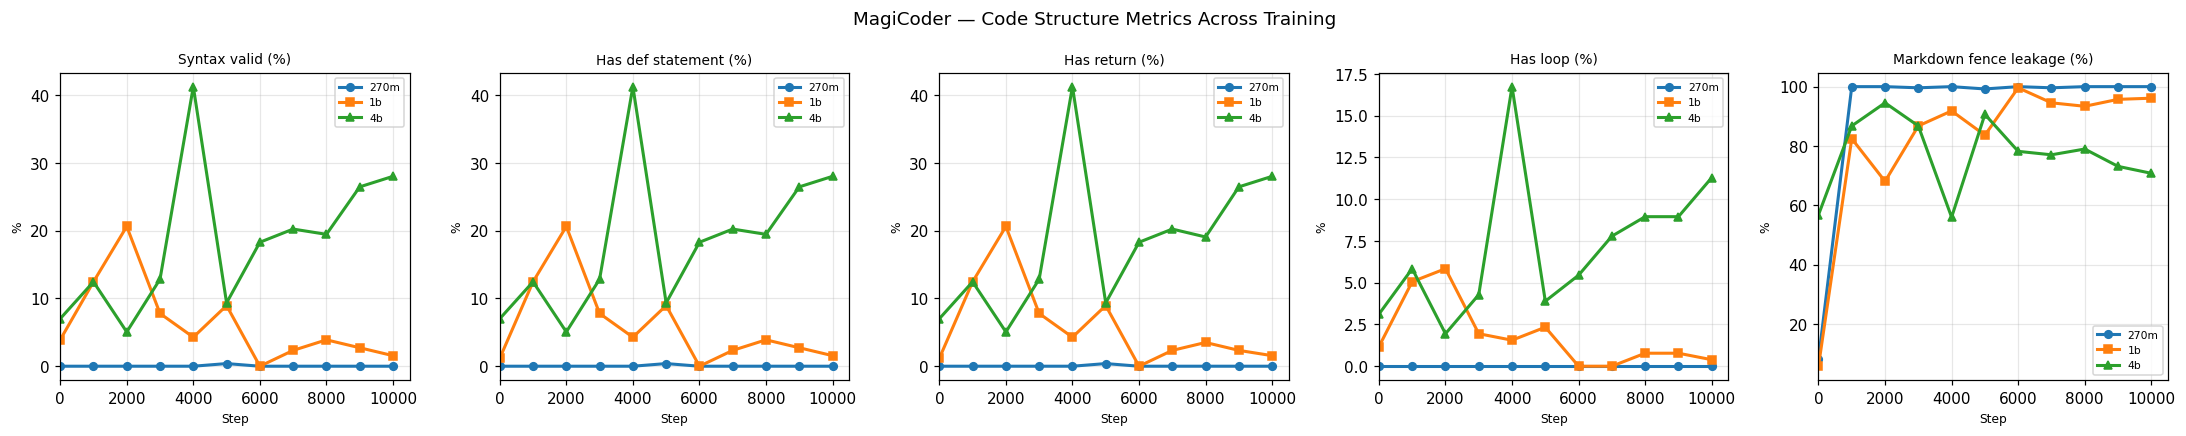


AST metrics plot saved.


In [13]:
# ── Cell F: AST metrics per checkpoint ───────────────────────────────────────
# Analyses full generated code (not truncated) using Python's ast module.
# Metrics: syntax valid %, has def %, has return %, has loop %,
#          uses builtins %, avg function length (lines), markdown leakage %

import ast as _ast
import re as _re

BUILTINS = {"len", "range", "sorted", "sum", "min", "max", "list", "dict",
            "set", "tuple", "zip", "map", "filter", "enumerate", "any", "all",
            "isinstance", "print", "str", "int", "float", "abs"}

def ast_metrics(code_str):
    """Extract AST-level metrics from a generated code string."""
    m = {
        "has_def":       False,
        "has_return":    False,
        "has_loop":      False,
        "has_cond":      False,
        "uses_builtin":  False,
        "func_lines":    0,
        "fence_leak":    "```" in code_str,
        "syntax_valid":  False,
    }
    try:
        tree = _ast.parse(code_str)
        m["syntax_valid"] = True
    except SyntaxError:
        return m

    for node in _ast.walk(tree):
        if isinstance(node, _ast.FunctionDef):
            m["has_def"] = True
            m["func_lines"] = max(m["func_lines"],
                                  getattr(node, "end_lineno", 0) - node.lineno + 1)
        if isinstance(node, _ast.Return):
            m["has_return"] = True
        if isinstance(node, (_ast.For, _ast.While)):
            m["has_loop"] = True
        if isinstance(node, (_ast.If, _ast.IfExp)):
            m["has_cond"] = True
        if isinstance(node, _ast.Call):
            fname = ""
            if isinstance(node.func, _ast.Name):
                fname = node.func.id
            elif isinstance(node.func, _ast.Attribute):
                fname = node.func.attr
            if fname in BUILTINS:
                m["uses_builtin"] = True
    return m

print(f"{'='*75}")
print(f"  AST Metrics per checkpoint (% of 257 problems)")
print(f"{'='*75}")
hdr = f"  {'label':<20}  {'syntx%':>6}  {'def%':>5}  {'ret%':>5}  {'loop%':>6}  {'cond%':>6}  {'bltn%':>6}  {'fnlen':>6}  {'fence%':>6}"
print(hdr)
print(f"  {'-'*75}")

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

all_ast_rows = {}
for size in SIZE_ORDER:
    ordered = get_ordered_labels(size)
    if not ordered:
        continue
    print(f"\n  -- {size} --")
    size_rows = []
    for label, step in ordered:
        data = all_results.get((size, label, step), {})
        if not data:
            continue
        agg = defaultdict(list)
        for v in data.values():
            code = v.get("code", "")
            mets = ast_metrics(code)
            for k_, val in mets.items():
                agg[k_].append(val)
        n = len(data)
        def pct(key): return sum(agg[key]) / n * 100
        def avg(key): return sum(agg[key]) / n

        row = {
            "label":        label,
            "step":         step,
            "syntax_pct":   pct("syntax_valid"),
            "def_pct":      pct("has_def"),
            "return_pct":   pct("has_return"),
            "loop_pct":     pct("has_loop"),
            "cond_pct":     pct("has_cond"),
            "builtin_pct":  pct("uses_builtin"),
            "avg_func_lines": avg("func_lines"),
            "fence_pct":    pct("fence_leak"),
        }
        size_rows.append(row)
        print(f"  {label:<20}  {row['syntax_pct']:>6.1f}  {row['def_pct']:>5.1f}  "
              f"{row['return_pct']:>5.1f}  {row['loop_pct']:>6.1f}  {row['cond_pct']:>6.1f}  "
              f"{row['builtin_pct']:>6.1f}  {row['avg_func_lines']:>6.1f}  {row['fence_pct']:>6.1f}")
    all_ast_rows[size] = size_rows

# Plot syntax validity and def% across checkpoints
if HAS_MPL:
    import numpy as np
    colors  = {"270m": "#1f77b4", "1b": "#ff7f0e", "4b": "#2ca02c"}
    markers = {"270m": "o", "1b": "s", "4b": "^"}
    metrics_to_plot = [
        ("syntax_pct",  "Syntax valid (%)"),
        ("def_pct",     "Has def statement (%)"),
        ("return_pct",  "Has return (%)"),
        ("loop_pct",    "Has loop (%)"),
        ("fence_pct",   "Markdown fence leakage (%)"),
    ]
    fig, axes = plt.subplots(1, len(metrics_to_plot),
                              figsize=(4*len(metrics_to_plot), 4), sharey=False)
    for ax, (metric, title) in zip(axes, metrics_to_plot):
        for size in SIZE_ORDER:
            rows = all_ast_rows.get(size, [])
            if not rows:
                continue
            xs = [r["step"] for r in rows]
            ys = [r[metric] for r in rows]
            ax.plot(xs, ys, marker=markers[size], color=colors[size],
                    label=size, linewidth=2, markersize=5)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Step", fontsize=8)
        ax.set_ylabel("%", fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
        ax.set_xlim(left=0)
    fig.suptitle("MagiCoder — Code Structure Metrics Across Training", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "ast_metrics.png"), bbox_inches="tight")
    plt.show()
    print("\nAST metrics plot saved.")

### Cell G — Regression Analysis

In [14]:
# ── Cell G: Regression analysis ──────────────────────────────────────────────
# Tasks that were solved at some checkpoint but failed later.
# Also shows tasks solved by base but broken by fine-tuning.

for size in SIZE_ORDER:
    ordered = get_ordered_labels(size)
    if not ordered:
        continue
    labels = [l for l, _ in ordered]
    steps  = [s for _, s in ordered]
    all_task_ids = sorted(
        all_results.get((size, ordered[0][0], ordered[0][1]), {}).keys(),
        key=lambda x: int(x)
    )
    if not all_task_ids:
        continue

    # Build pass matrix
    matrix = {}
    for tid in all_task_ids:
        matrix[tid] = {}
        for label, step in ordered:
            data = all_results.get((size, label, step), {})
            matrix[tid][label] = data.get(str(tid), {}).get("passed_all", False)

    # Tasks where a later checkpoint FAILS after an earlier one PASSED
    regressions = []
    for tid in all_task_ids:
        passes = [matrix[tid].get(l, False) for l in labels]
        for i in range(len(passes) - 1):
            if passes[i] and not passes[i+1]:
                regressions.append({
                    "task_id":   tid,
                    "last_pass": labels[i],
                    "first_fail":labels[i+1],
                })
                break

    # Tasks base solved but fine-tuning broke (special case: harmful fine-tuning)
    base_label = ordered[0][0]
    base_broken = [tid for tid in all_task_ids
                   if matrix[tid].get(base_label)
                   and not matrix[tid].get(ordered[-1][0])]

    print(f"\n{'='*60}")
    print(f"  Regression analysis: {size}")
    print(f"{'='*60}")
    print(f"  Tasks with at least one regression:  {len(regressions)}")
    print(f"  Tasks base solved but final broke:   {len(base_broken)}")
    if regressions:
        print(f"\n  Detail (first regression per task):")
        print(f"  {'task_id':<10} {'last_pass':<20} {'first_fail':<20}")
        print(f"  {'-'*50}")
        for r in regressions[:15]:  # show up to 15
            print(f"  {r['task_id']:<10} {r['last_pass']:<20} {r['first_fail']:<20}")
        if len(regressions) > 15:
            print(f"  ... and {len(regressions)-15} more")


  Regression analysis: 270m
  Tasks with at least one regression:  8
  Tasks base solved but final broke:   0

  Detail (first regression per task):
  task_id    last_pass            first_fail          
  --------------------------------------------------
  127        ckpt_6000            ckpt_7000           
  132        ckpt_3000            ckpt_4000           
  246        ckpt_7000            ckpt_8000           
  292        ckpt_3000            ckpt_4000           
  404        ckpt_1000            ckpt_2000           
  433        ckpt_5000            ckpt_6000           
  451        ckpt_3000            ckpt_4000           
  456        ckpt_2000            ckpt_3000           

  Regression analysis: 1b
  Tasks with at least one regression:  63
  Tasks base solved but final broke:   2

  Detail (first regression per task):
  task_id    last_pass            first_fail          
  --------------------------------------------------
  12         ckpt_5000            ckpt_6000  